# generate KD plots from cumulant fit results

In [4]:
import numpy as np              
import matplotlib.pyplot as plt  
import os                       
import bayes_fit as bf          
import glob                     
import pandas as pd
# %matplotlib widget                     

In [5]:
res_dir = r'C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\Results'
files = glob.glob(res_dir + r'\\*.npz')
print(len(files))

320


20250124_at1r-g13_measurement1b_set10_cumulant_LS_fit.npz
brightnesses: 4.444 2.842


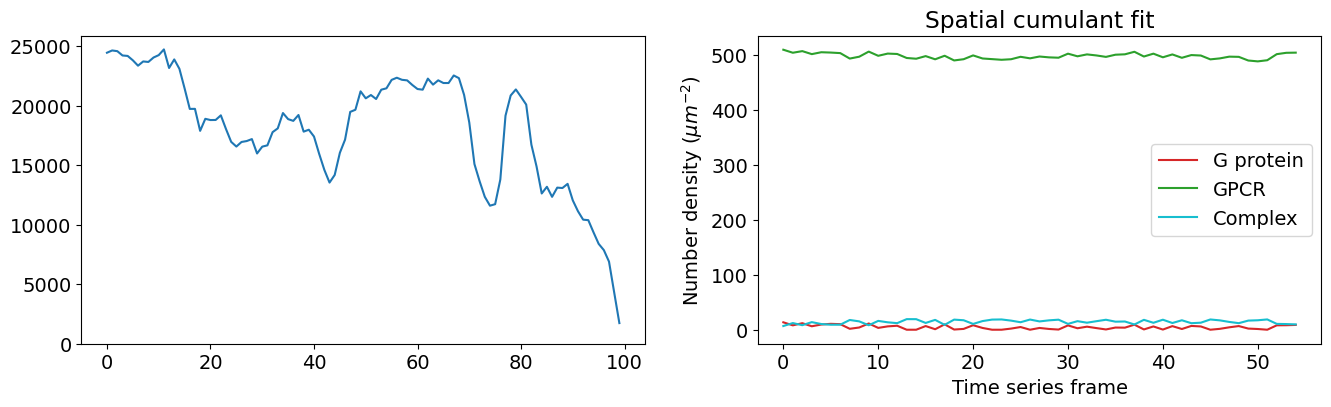

In [7]:
i = 0

f = np.load(files[i])
fname = files[i][len(res_dir) + 1:]
print(fname)

for i in [1]:
    Rvals = f['Rvals']
    Gvals = f['Gvals']
    RGvals = f['RGvals']
    yfpvals = f['yfpvals']
    mchvals = f['mchvals']
    Npixels = f['Npixels']
    print('brightnesses:', np.median(yfpvals), np.median(mchvals))
    where = np.ones(Rvals.shape, dtype='bool')
    where[Npixels < 0.75*np.max(Npixels)] = 0

# where[:30] = 0

for i in [1]:
    Ruse = Rvals[where]
    Guse = Gvals[where]
    RGuse = RGvals[where]

    plt.rcParams.update({"font.size":14})
    plt.subplots(1, 2, figsize=(16, 4))
    plt.subplot(1,2,1)
    plt.plot(Npixels)
    plt.ylim(ymin=0)
    plt.subplot(1,2,2)
    # plt.figure(figsize=(7, 5))
    plt.title('Spatial cumulant fit')
    plt.plot(Guse*44, label='G protein', color='tab:red')
    plt.plot(Ruse*44, label='GPCR', color='tab:green')
    plt.plot(RGuse*44, label='Complex', color='tab:cyan')
    plt.xlabel('Time series frame')
    plt.ylabel('Number density ($\mu m^{-2}$)')
    plt.legend()
    plt.show()


N_R > N_G: True 512.955911262928 18.903418588005714
N_R > N_G: True 512.955911262928 18.903418588005714


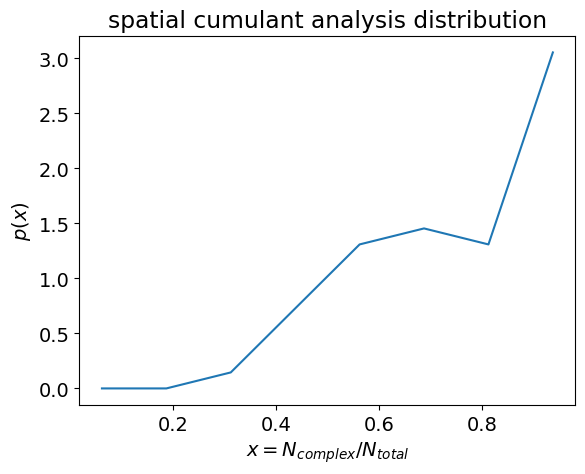

334.9164923798031 728.8021673220643


In [8]:
N_R = np.mean(Ruse+RGuse)*44
N_G = np.mean(Guse+RGuse)*44
print('N_R > N_G:', N_R > N_G, N_R, N_G)
if not N_R > N_G:
    N_R, N_G = N_G, N_R
    x_fits = RGuse/(RGuse + Ruse)
else:
    x_fits = RGuse/(RGuse + Guse)
print('N_R > N_G:', N_R > N_G, N_R, N_G)


xvals, xbins = np.histogram(x_fits, np.linspace(0, 1, int(N_G)//2), density=True)

xpos = xpos = xbins[:-1] + np.diff(xbins)/2

plt.figure()
plt.title('spatial cumulant analysis distribution')
plt.ylabel('$p(x)$')
plt.xlabel(r'$x = N_{complex}/N_{total}$')
plt.plot(xpos, xvals, label='Image data histogram')
plt.show()
minseed, maxseed = bf.get_seed(N_G, N_R, offset=0, maxval=True)
print(minseed, maxseed)



maximum likelihood:  423.2271659974311
integral 0.9999999999999999
maximum a posteriori:  423.01054600751564 (+/-)
14.355153213516246


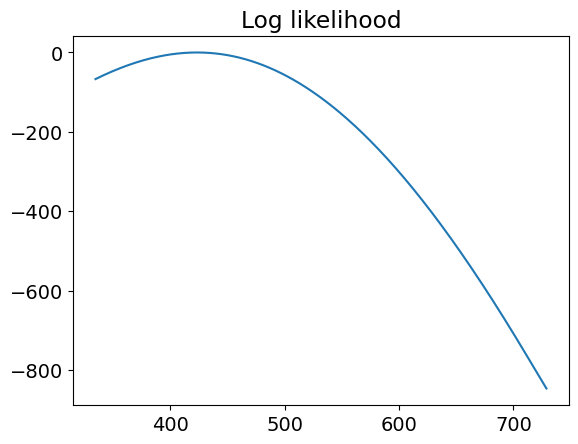

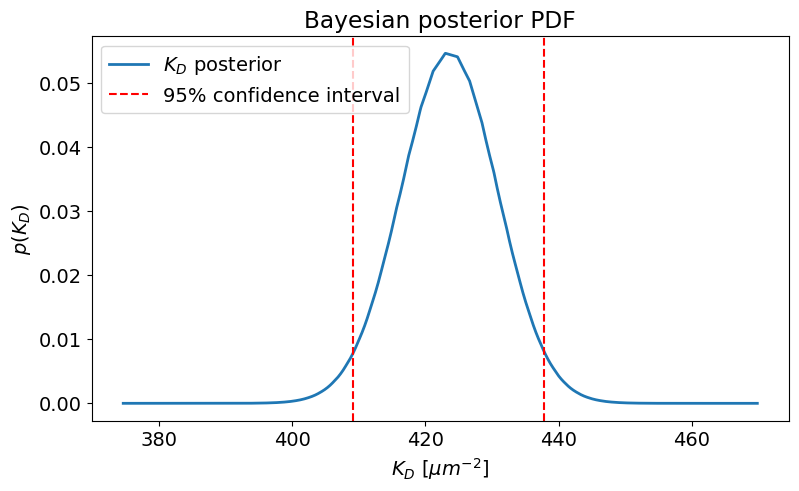

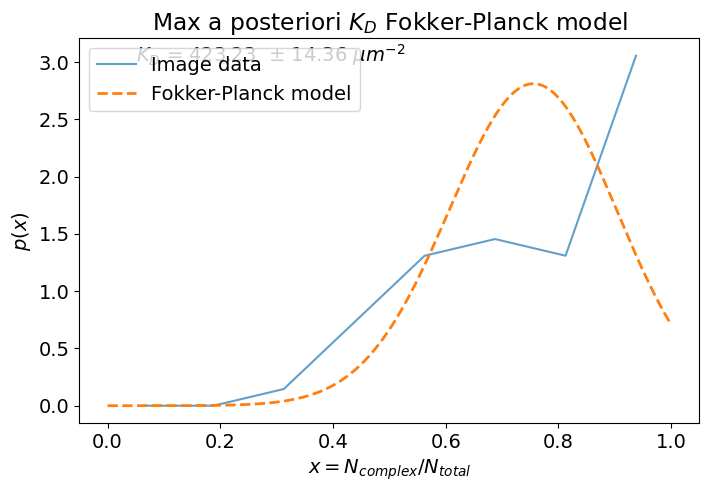

In [9]:

KD_grid = np.linspace(minseed, maxseed, int(maxseed-minseed)*2)
# print(x_fits)

log_likelihood, KD_grid = bf.log_likelihood_KD(x_fits, KD_grid, N_G, N_R, maxval=0)
log_likelihood[np.logical_not(np.isfinite(log_likelihood))] = -np.inf
log_likelihood = log_likelihood - (np.max(log_likelihood))

# KD_grid, log_likelihood = KD_grid[1:-2], log_likelihood[1:-2]

posterior = np.exp(log_likelihood) / (np.sum(np.exp(log_likelihood))*np.diff(KD_grid)[0])
plt.figure()
plt.title('Log likelihood')
plt.plot(KD_grid, log_likelihood)

# print(log_likelihood)
print('maximum likelihood: ', KD_grid[np.argmax(log_likelihood)])

# k = np.linspace(minseed+0.5, maxseed-0.5, 100)
# diffvals = np.zeros(len(k))

# just for plotting the best fit
k = KD_grid[np.argmax(log_likelihood)]
xgrid = np.linspace(0,1, 500)
logpdf = bf.log_steady_contKD(xgrid, k, N_G, N_R)
logpdf = logpdf - np.min(logpdf)
pdf = np.exp(logpdf)
pdf = pdf / (np.sum(pdf)*np.diff(xgrid)[0])
print('integral', np.sum(pdf)*np.diff(xgrid)[0])

# print(logpdf)

bounds = bf.get_confidence_interval(posterior, KD_grid, 1-1e-10)
# plt.figure()
# plt.plot(KD_grid, bounds)
# plt.title('testing')
# plt.show()

new_grid = np.linspace(bounds[0], bounds[1], max(len(KD_grid), 2000))
log_likelihood, new_grid = bf.log_likelihood_KD(x_fits, new_grid, N_G, N_R, maxval=0)
log_likelihood[np.logical_not(np.isfinite(log_likelihood))] = -np.inf
log_likelihood = log_likelihood - np.max(log_likelihood)
posterior = np.exp(log_likelihood) / (np.sum(np.exp(log_likelihood))*np.diff(new_grid)[0])
MAPKD = new_grid[np.argmax(log_likelihood)]

interval = 0.95
diffvals = bf.get_confidence_interval(posterior, new_grid, interval)
# print(diffvals)

print('maximum a posteriori: ', new_grid[np.argmax(posterior)], '(+/-)', )
print((diffvals[1] - diffvals[0])/2)

res_dict = {'file name':[fname],
            'cut_data_KD':[MAPKD],
            'cut_95_min':[diffvals[0]],
            'cut_95_max':[diffvals[1]],
            'KD_range_min':[minseed],
            'KD_range_max':[maxseed],    
            'extrema':[]
}
if diffvals[0] == bounds[0] or diffvals[1] == bounds[1]:
    res_dict['extrema'].append(1)
else:
    res_dict['extrema'].append(0)

plt.figure(figsize=(9,5))
plt.plot(new_grid, posterior, linewidth=2, label='$K_D$ posterior')
# plt.plot(KD_grid, posterior)
plt.title('Bayesian posterior PDF')
plt.xlabel(r'$K_D$ [$\mu m^{-2}$]')
plt.ylabel(r'$p(K_D)$')
plt.axvline(diffvals[0], ymin=0, ymax=1, color='r', linestyle='--', linewidth=1.5, label=f'{int(interval*100)}% confidence interval')
plt.axvline(diffvals[1], ymin=0, ymax=1, color='r', linestyle='--', linewidth=1.5)
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.title('Max a posteriori $K_D$ Fokker-Planck model')
plt.plot(xpos, xvals, alpha=0.7, linewidth=1.5, label='Image data')
plt.plot(xgrid, pdf, '--', linewidth=2, label='Fokker-Planck model')
plt.xlabel(r'$x = N_{complex}/N_{total}$')
plt.ylabel('$p(x)$')
plt.text(0.05, 3, r"$K_D$ = %s  $\pm$ %s $\mu m^{-2}$" % (round(k, 2), round((diffvals[1] - diffvals[0])/2, 2)), fontdict={"fontsize":14})
plt.legend()
plt.show()

df = pd.DataFrame(res_dict)
df.to_clipboard(excel=True, index=False, header=None)

# below is for presentation purposes

In [178]:
# # broken axis plot is nice for showing the KD posterior
# print(KD_grid[0], KD_grid[-1])

# fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(9, 5))
# fig.subplots_adjust(wspace=0.05)  # adjust space between Axes

# # plot the same data on both Axes
# ax1.plot(KD_grid, posterior, linewidth=2, label='$K_D$ posterior')
# ax1.axvline(diffvals[0], ymin=0, ymax=1, color='r', linestyle='--', linewidth=1.5, label=f'{int(interval*100)}% confidence interval')
# ax2.axvline(800, ymin=0, ymax=1, color='r', linestyle='--', linewidth=1.5, label=f'{int(interval*100)}% confidence interval') # just for the label lol
# ax1.axvline(diffvals[1], ymin=0, ymax=1, color='r', linestyle='--', linewidth=1.5)
# ax2.plot(KD_grid, posterior, linewidth=2, label='$K_D$ posterior')

# # zoom-in / limit the view to different portions of the data
# ax1.set_xlim(30, 160)  # outliers only
# ax2.set_xlim(560, 705)  # most of the data

# # hide the spines between ax and ax2
# ax1.spines.right.set_visible(False)
# ax2.spines.left.set_visible(False)
# ax2.tick_params(left=False)  # don't put tick labels at the left
# ax1.set_ylabel(r'$p(K_D)$')
# plt.figtext(0.5, 0., r'$K_D$ [$\mu m^{-2}$]', ha='center', va='center') # shared x label

# # Now, let's turn towards the cut-out slanted lines.
# # We create line objects in axes coordinates, in which (0,0), (0,1),
# # (1,0), and (1,1) are the four corners of the Axes.
# # The slanted lines themselves are markers at those locations, such that the
# # lines keep their angle and position, independent of the Axes size or scale
# # Finally, we need to disable clipping.

# d = .5  # proportion of vertical to horizontal extent of the slanted line
# kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
#               linestyle="none", color='k', mec='k', mew=1, clip_on=False)
# ax1.plot([1, 1], [1, 0], transform=ax1.transAxes, **kwargs)
# ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
# plt.legend()
# plt.suptitle('Bayesian posterior PDF')


# plt.show()